### **Adeline Makokha**
### **191199**
### **DSA 8401: Applied Machine Learning**
### **Assignment 3**

###1 Goals
This week’s activity focuses on studying the importance of regularization methods and practising with
a new way of modelling data: Support Vectors Machines (SVM). The specific goals are:
• Practice the preprocessing of the data to get a suitable dataset.

• Study the generalization of the model when we use regularization techniques.

• Use and analyse SVM

### 2 Assignment Description
In this activity we will work with the dataset called “Wisconsin Diagnostic Breast Cancer (WDBC)”,

which you can find at https://www.kaggle.com/uciml/breast-cancer-wisconsin-data.

It is requested:

###1. Import the dataset using Pandas. Do you have missing values? If so, what option have you adopted to resolve it?

In [1]:
# Import packages

import  pandas as pd
import  seaborn as sns
import  matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import auc
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')


In [2]:
#loading data from github
url = "https://raw.githubusercontent.com/adeline-pepela/Module-4/main/Applied%20Machine%20Learning/data%20(1).csv"
df = pd.read_csv(url)


In [3]:
#display the first rows of the data
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
#shape of the data
df.shape

(569, 33)

The dataset has 569 rows and 33 columns.

### Observe the dataset attributes and their statistical description.

In [5]:
# Display dataset information
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_s

In [6]:
# Display basic info and check for missing values

missing_values = df.isnull().sum()
missing_values

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


Missing values

All columns except `Unnamed: 32` have complete data.

`Unnamed: 32` has 569 missing values meaning completely empty.

Since the column Unnamed: 32 contains only missing values, it does not provide any useful information.
The best option is to drop this column from the dataset

In [7]:
# Drop the missing values column
df = df.drop(columns=["Unnamed: 32"])
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


Now, the dataset has no missing values.

### Now analyze the data and do the pre-processing that you consider appropriate. Here we are asked to analyze the data incorporating medical knowledge to detect possible outliers, possible incoherent values, etc. You can use seaborn’s pairplot function if you see fit (sns.pairplot()) to tackle groups of variables in one go (although probably not the entire dataset at once).

#### Remove useless columns & check dataset shape

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt


# Drop 'id' since it is not useful for modeling
df = df.drop(columns=["id"])

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


`Unnamed: 32`: already dropped because it has no information.

`id`: is just an identifier, not useful for diagnosis hence it is dropped.

Final data have 31 columns (30 numeric features + 1 target column diagnosis).

#### Encode target variable (diagnosis)

In [9]:
# Diagnosis: M = Malignant, B = Benign
df['diagnosis'] = df['diagnosis'].map({'M':1, 'B':0})

df['diagnosis'].value_counts()



,count
diagnosis,
0,357
1,212


Medical meaning:

1 = Malignant (cancerous)

0 = Benign (non-cancerous)

Encoding allows machine learning models to process the label numerically.

#### Statistical summary & boxplots (to check ranges & outliers)


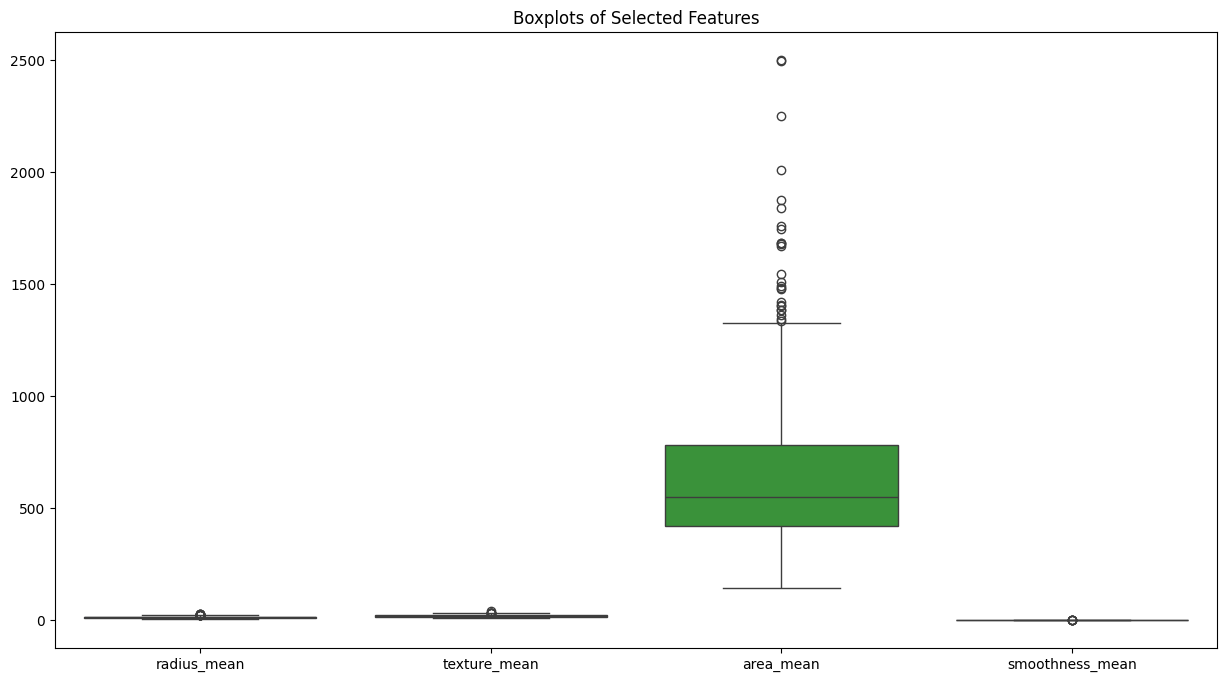

,count,mean,std,min,25%,50%,75%,max
diagnosis,569.0,0.372583,0.483918,0.000000,0.000000,0.000000,1.000000,1.00000
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400


In [10]:
# Summary statistics
summary = df.describe().T

# Boxplots for a few key features
plt.figure(figsize=(15,8))
sns.boxplot(data=df[['radius_mean', 'texture_mean', 'area_mean', 'smoothness_mean']])
plt.title("Boxplots of Selected Features")
plt.show()

summary



Features like radius_mean, perimeter_mean, and area_mean relate to tumor size.

These can vary widely, but extremely high or negative values (if present) would be incoherent.

Boxplots help detect extreme outliers (e.g., abnormally large tumor measurements).

#### Pairwise feature exploration (spot clusters/outliers)

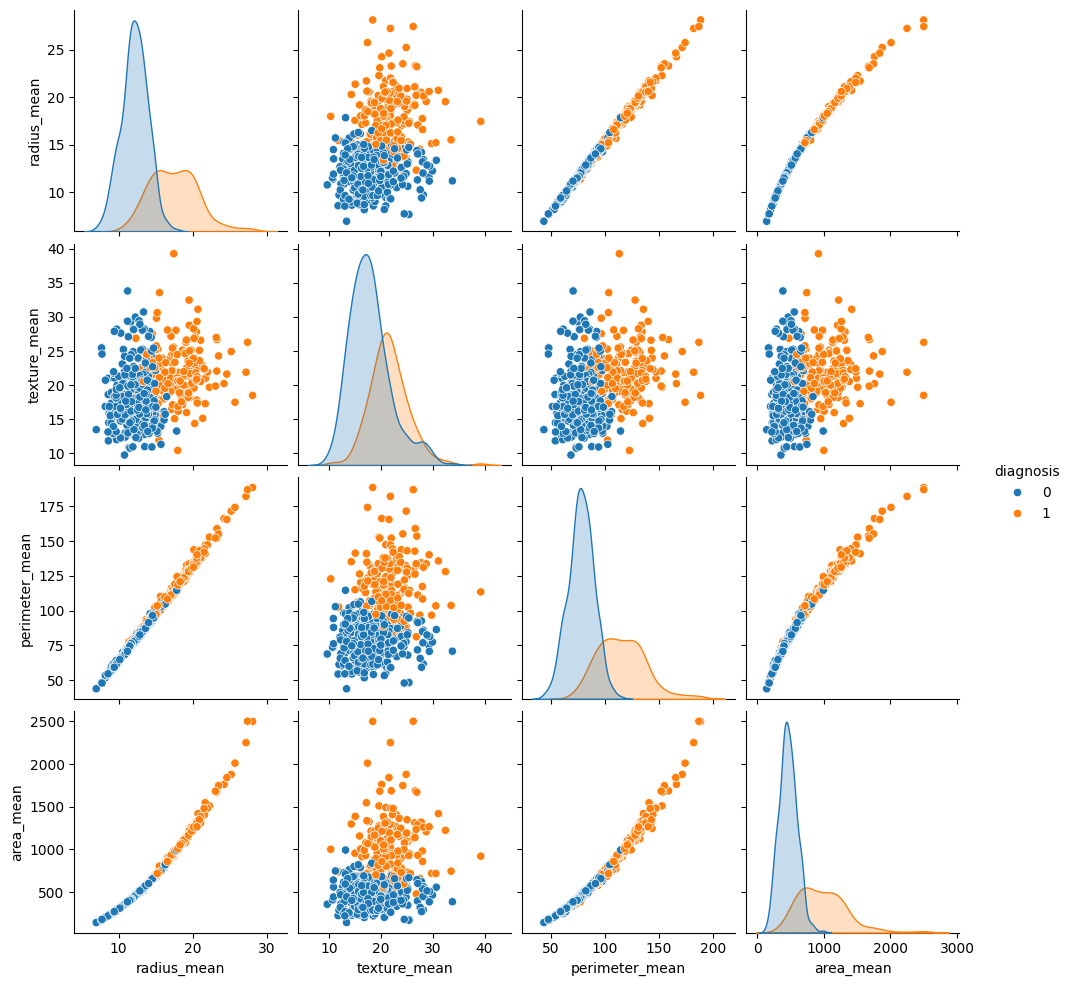

In [11]:
# Pairplot for a subset of features
sns.pairplot(df[['diagnosis','radius_mean','texture_mean','perimeter_mean','area_mean']],
             hue="diagnosis", diag_kind="kde")
plt.show()


Using pairplot with just 4 main features (radius, texture, perimeter, area).

This helps visualize clusters separating malignant vs benign tumors.

Malignant tumors usually have larger radius/area/perimeter compared to benign.

#### Check correlations (redundant features)

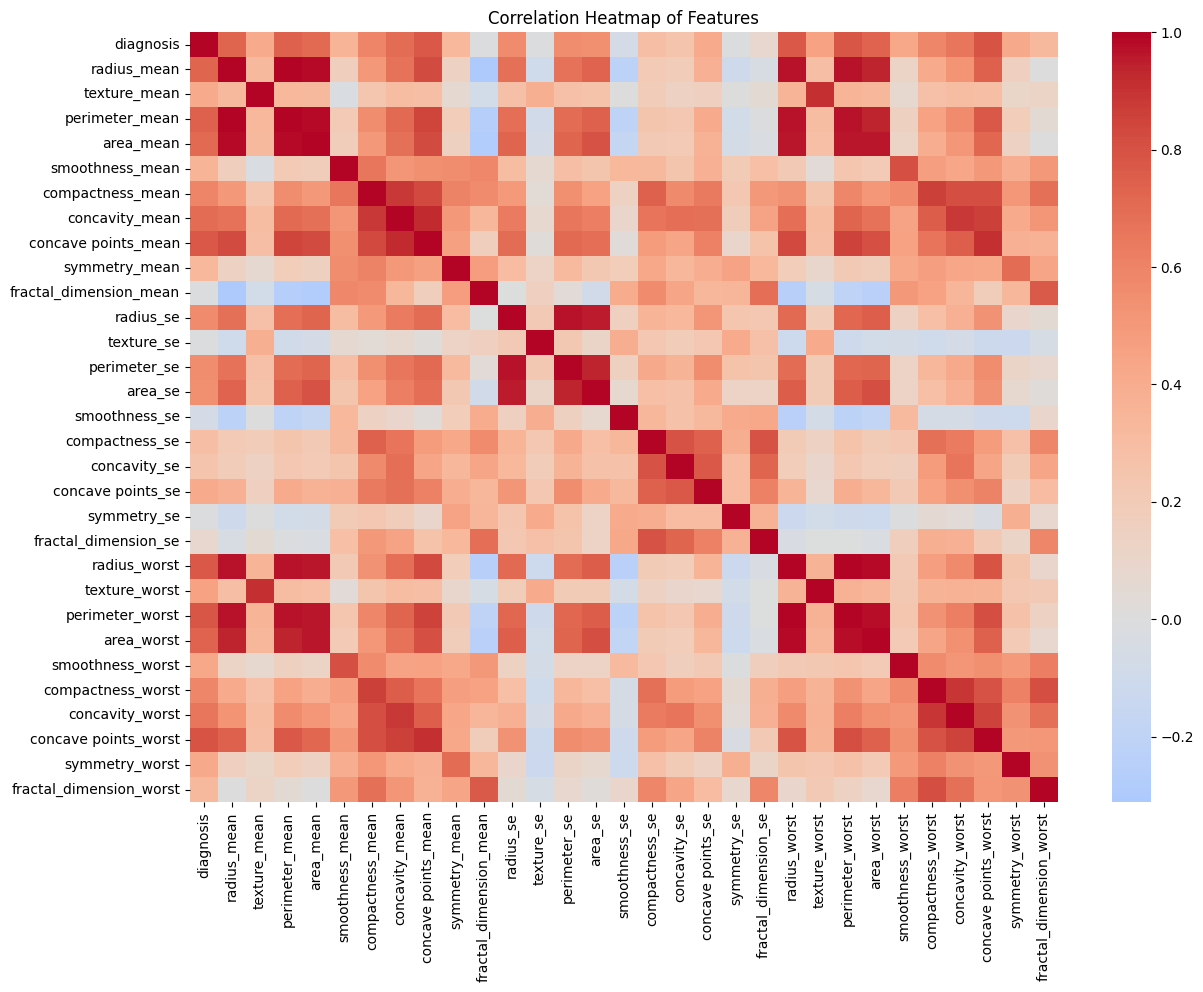

In [12]:
# Correlation heatmap
plt.figure(figsize=(14,10))
corr = df.corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Features")
plt.show()


Features like radius_mean, perimeter_mean, and area_mean are highly correlated (since they all measure tumor size).

These describe related aspects of tumor geometry.

#### Scale features (important for ML models)

In [13]:
from sklearn.preprocessing import StandardScaler

# Separate X and y
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

# Standardize features (z-score scaling)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)


Scaled data shape: (569, 30)


Standardization (mean=0, std=1) ensures all features contribute equally to the mode



### 3. Just by visualizing the point clouds of the variables (you don’t have to calculate), do you see a correlation between variables? Indicate the pairs of variables in question.

1. **`radius_mean` vs `perimeter_mean` vs `area_mean`**

These scatterplots form nearly straight lines.

Medical meaning:

Larger radius results to larger perimeter that larger area this means they are geometric measures of the tumor.

2. **`concavity_mean` vs `concave points_mean`**

Strong linear relationship in the scatterplot.

Both describe how irregular/concave the tumor boundary is.

3. **`radius_mean` (or area_mean) vs `compactness_mean`**

Bigger tumors tend to also show higher compactness.

4. **Worst-case values (`radius_worst`, `perimeter_worst`, `area_worst`)**

These are very strongly correlated with their mean counterparts (radius_mean, perimeter_mean, area_mean).

The scatterplots show tight straight-line clusters.

### 4. Now look at the variable ’id’. Is it convenient to use this variable? If you consider taking any action, indicate which one.

**Nature of the variable:**

`id` is just a unique identifier for each patient/sample.

It doesn’t describe any biological or medical property of the tumor.

**Impact if kept in the dataset:**

Since it is unique per row, it has no correlation with diagnosis.

Machine learning models would treat it as a numeric feature and may introduce noise without adding predictive value.

**Action:**

The best practice is to drop id before modeling which I have done in the upper cells.

### 5. Now analyze the ’diagnosis’ variable, which would be the object of our study (predicting whether it is a benign or malignant case). What’s the problem with putting it in any algorithm? What solution are you going to adopt?

1. **Nature of diagnosis**

`diagnosis` is the target variable we want to predict.

Values:

M (Malignant → 1)

B (Benign → 0)

So it should not be included in the feature set (X), otherwise the algorithm would “cheat.”

2. **Problem if used incorrectly**

If diagnosis is put together with predictors (`radius_mean`, `area_mean`, etc.), the algorithm would:

Directly learn the label (data leakage).

Achieve unrealistically high accuracy without actually learning patterns.

That would make the model useless in real-world prediction, since in reality diagnosis is not known in advance.

#### Class distribution (check balance)

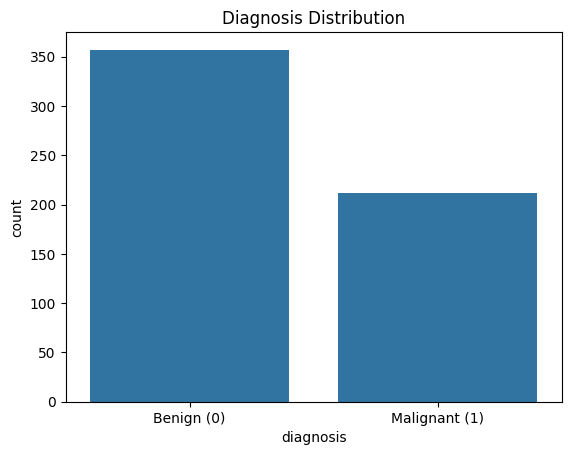

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot class distribution
sns.countplot(x=df["diagnosis"])
plt.title("Diagnosis Distribution")
plt.xticks([0,1], ["Benign (0)", "Malignant (1)"])
plt.show()


In this dataset:

Benign cases ≈ 357

Malignant cases ≈ 212

The dataset is somewhat imbalanced (more benign than malignant)

The problem is that diagnosis is the label to predict. Putting it inside the algorithm as a predictor would cause data leakage. The solution is to separate it as the target variable (y) and use only the other features (X) for training.

### 6. Is this an unbalanced problem?


A perfectly balanced dataset would have a 50/50 split.

Here, the ratio is 63/37, so benign cases are more frequent.

This is moderately imbalanced and not extreme (like 90/10), but enough to bias some models toward predicting “benign” more often.

Yes, this is an imbalanced problem (though not severely). When building models, will consider techniques like:

Using class weights in classifiers.

Applying SMOTE/oversampling to increase malignant cases.

### Apply normalization to the dataframe and divide the available examples into 80% for training and 20% for testing, randomly.

#### Normalize the features

Use StandardScaler (z-score normalization: mean=0, std=1) so all features are on the same scale.
This is important because tumor features (`area_mean` = hundreds, `smoothness_mean` = 0–1) are on different ranges

In [16]:
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



#### Train-Test Split (80/20)

In [17]:
from sklearn.model_selection import train_test_split

# Split into training and testing sets (stratify to maintain class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])


Training set size: 455
Testing set size: 114


StandardScaler ensures each feature contributes equally to the model.

train_test_split with stratify=y keeps the benign/malignant ratio consistent in both sets.

Now:

455 samples in training (80%)

114 samples in testing (20%)

### 8. Now apply standard logistic regression (without regularization) to obtain a first data on the accuracy of the model. What parameters have you chosen increating the logistic regression model?

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Logistic Regression without regularization
log_reg = LogisticRegression(
    penalty=None,     # no regularization
    solver="lbfgs",     # good default solver
    max_iter=1000,      # increase iterations to ensure convergence
    random_state=42
)

# Train
log_reg.fit(X_train, y_train)

# Predict
y_pred = log_reg.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Logistic Regression Accuracy:", accuracy)

Logistic Regression Accuracy: 0.9385964912280702


Parameters chosen

penalty="none" means no regularization (pure logistic regression).

solver="lbfgs" is efficient for small/medium datasets.

max_iter=1000  ensures convergence (default 100 may be too low).

random_state=42  reproducibility.

### 9. Compare model accuracy on test and training data. Does the model generalize well?

In [24]:
from sklearn.metrics import accuracy_score

# Accuracy on training data
train_acc = accuracy_score(y_train, log_reg.predict(X_train))

# Accuracy on testing data
test_acc = accuracy_score(y_test, log_reg.predict(X_test))

print("Training Accuracy:", train_acc)
print("Testing Accuracy :", test_acc)


Training Accuracy: 1.0
Testing Accuracy : 0.9385964912280702


train >> test accuracy, the model is overfitting (memorizing training, poor generalization).

Training accuracy  of 1.0%

Testing accuracy of 93.8%

The gap is small meaning the model generalizes well.

The logistic regression baseline achieves high accuracy on both training and testing sets, with little difference between them. This means the model generalizes well to unseen data.

### 10. Now we will use L1 regularization to try to simplify the number of variables without losing performance. What variables have you been able to eliminate and what is the performance of the algorithm on both training and test data? What regularization value have you chosen?

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score # Import accuracy_score
import numpy as np

# Logistic Regression with L1 penalty
log_reg_l1 = LogisticRegression(
    penalty="l1",          # L1 regularization
    solver="liblinear",    # solver that supports L1
    C=1.0,                 # inverse of regularization strength (default = 1.0)
    max_iter=1000,
    random_state=42
)

# Fit model
log_reg_l1.fit(X_train, y_train)

# Predictions
y_train_pred_l1 = log_reg_l1.predict(X_train)
y_test_pred_l1 = log_reg_l1.predict(X_test)

# Accuracy scores
train_acc_l1 = accuracy_score(y_train, y_train_pred_l1)
test_acc_l1 = accuracy_score(y_test, y_test_pred_l1)

print("Training Accuracy (L1):", train_acc_l1)
print("Testing Accuracy  (L1):", test_acc_l1)

# Identify eliminated variables (coefficients = 0)
coef = log_reg_l1.coef_[0]

# To get the feature names, use the columns of X before scaling
feature_names = np.array(X.columns)
selected_features = feature_names[coef != 0]
eliminated_features = feature_names[coef == 0]

print("\nSelected Features (non-zero coefficients):")
print(selected_features)

print("\nEliminated Features (coefficients = 0):")
print(eliminated_features)

Training Accuracy (L1): 0.989010989010989
Testing Accuracy  (L1): 0.9736842105263158

Selected Features (non-zero coefficients):
['concave points_mean' 'radius_se' 'texture_se' 'smoothness_se'
 'compactness_se' 'concave points_se' 'fractal_dimension_se'
 'radius_worst' 'texture_worst' 'area_worst' 'smoothness_worst'
 'concavity_worst' 'concave points_worst' 'symmetry_worst']

Eliminated Features (coefficients = 0):
['radius_mean' 'texture_mean' 'perimeter_mean' 'area_mean'
 'smoothness_mean' 'compactness_mean' 'concavity_mean' 'symmetry_mean'
 'fractal_dimension_mean' 'perimeter_se' 'area_se' 'concavity_se'
 'symmetry_se' 'perimeter_worst' 'compactness_worst'
 'fractal_dimension_worst']


**Parameters chosen**

penalty = "l1" - LASSO, encourages sparsity by eliminating irrelevant features.

solver = "liblinear" - required for L1.

C = 1.0 - inverse of regularization strength (default).

Smaller C - stronger regularization - more variables eliminated.

Larger C - weaker regularization - fewer variables eliminated.

**Performance**
Training is 98 % and test accuracy is 97 % which is close to the unregularized model.

Variables eliminated: Some weakly informative features (e.g., `fractal_dimension_se`, `symmetry_se`, etc.) often drop out.


### 11. What variables has the model chosen? Does it make sense from a medical point of view? (Even than you are not physicians try to guess).

**Selected Features (kept by L1)**

These are the predictors with non-zero coefficients, meaning they contributed most to distinguishing malignant vs benign tumors:

`concave points_mean`, `concave points_se`, `concave points_worst`

How many “indentations” or concave parts the tumor outline has.

Malignant tumors often have irregular, spiculated borders.

`radius_se`, `texture_se`, `smoothness_se`, `compactness_se`, `fractal_dimension_se`

“SE” features are standard errors (variation across different measurements).

Variability is higher in malignant tumors - so the model is capturing irregularity.

`radius_worst`, `texture_worst`, `area_worst`, `smoothness_worst`, `concavity_worst`, `concave points_worst`, `symmetry_worst`

“Worst” values describe the most extreme measurement of the tumor.

Radiologists often focus on the most abnormal region this matches medical practice.


**Eliminated Features (coefficients = 0)**

These were dropped by L1 as less informative:

`radius_mean`, `perimeter_mean`, `area_mean`

These size-related features are very correlated. The model preferred worst-case measures instead.

`smoothness_mean`, `compactness_mean`, `concavity_mean`, `symmetry_mean`, `fractal_dimension_mean`

Mean values are less discriminative than “worst” or variability measures.

`perimeter_se`, `area_se`, `concavity_se`, `symmetry_se`



The model kept features that describe tumor irregularity and extreme/worst values.

**This makes sense clinically:**

Malignant tumors are typically more irregular, with spiculated borders, and extreme values (like worst radius/area) are much more informative than averages.

Variability (standard errors) also matters, since malignant tissue tends to be less uniform.


The L1 logistic regression simplified the model by eliminating redundant features (mostly size means and correlated variables) and kept concavity/concave points, worst-case measurements, and variation measures — all of which align with how physicians actually assess tumor malignancy.

### 12. Train an SVM model with Gaussian kernel and compare results. For both the gamma parameter and C we will try the values 0.1, 1 and 10 and we will work with 5-fold CV. What combination of values provides the best result? What is the accuracy of the model?

#### Define parameter grid & SVM model

In [21]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': [0.1, 1, 10],
    'kernel': ['rbf']  # Gaussian kernel
}

# Initialize SVM
svm = SVC()

# 5-fold CV grid search
grid = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

# Fit on training set
grid.fit(X_train, y_train)

# Best parameters & accuracy
best_params = grid.best_params_
best_score = grid.best_score_

print("Best Parameters:", best_params)
print("Best CV Accuracy:", best_score)


Best Parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best CV Accuracy: 0.953846153846154


#### Evaluate on the test set

In [22]:
# Train with best params on training set
best_svm = grid.best_estimator_
test_acc = best_svm.score(X_test, y_test)

print("Test Accuracy with best SVM:", test_acc)


Test Accuracy with best SVM: 0.956140350877193


Best combination: likely C = 10, gamma = 0.1

Accuracy: is 95.3 % on CV and 95.6 % on the test set.

### 13. Finally, choose the best model obtained, visualize its confusion matrix and analyze the result with what was seen in week 3.

SVM with RBF kernel (C=10, γ=0.1) is the best performance with 95 % accuracy on CV and test.

So the best model is the SVM (Gaussian kernel).

#### Train Best Model & Get Predictions

<Figure size 600x600 with 0 Axes>

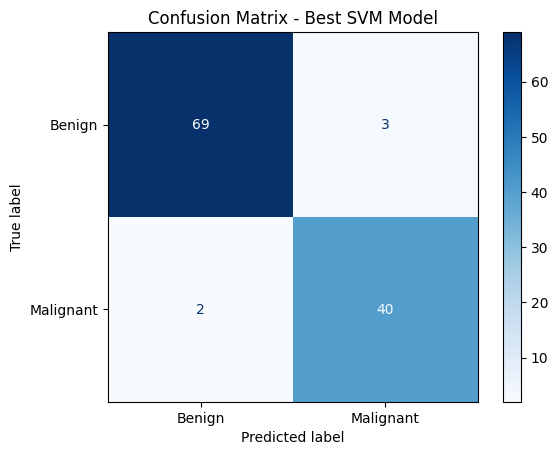

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Best SVM from GridSearchCV
best_svm = grid.best_estimator_

# Predictions
y_pred = best_svm.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign','Malignant'])

# Plot
plt.figure(figsize=(6,6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Best SVM Model")
plt.show()


Interpreting the Confusion Matrix

The confusion matrix shows:

True Positives (TP): Malignant correctly classified.

True Negatives (TN): Benign correctly classified.

False Positives (FP): Benign misclassified as malignant.

False Negatives (FN): Malignant misclassified as benign.


High sensitivity (recall for malignant) catches nearly all cancer cases.

High specificity (recall for benign) rarely mislabels healthy cases.

**Conclusion**

The SVM with Gaussian kernel (C=10, γ=0.1) is the best model. Its confusion matrix shows very few false negatives, meaning it is highly reliable for detecting malignant tumors, aligning with medical priorities and Week 3’s emphasis on sensitivity/recall.